In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

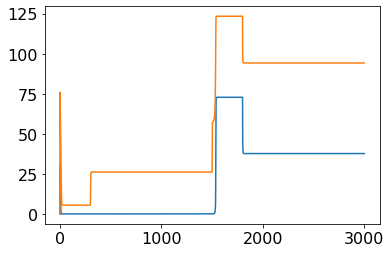

[[2.34744533e-04 2.60620262e+01]
 [3.76743691e+01 9.42167634e+01]]


In [124]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.01
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.01

low state vars =  [ 8.31271457e-005  2.58466929e+001 -3.30722262e-001  1.03265160e+000
  0.00000000e+000  1.64199046e-005  7.90230958e-001  1.53463121e-005
  8.79505058e-001  1.01354177e-006  2.59451245e-003  8.85337502e-007
  1.93172947e-003  2.39864491e-264  1.79898368e-264  1.50299007e+000
  1.48688653e+000 -7.09692976e+001  2.11528663e+001  2.30579002e+000]


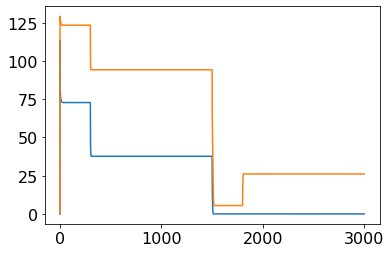

In [50]:
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1] * 0.99

print("low state vars = ", low_state_vars)

### State switching task in bistability regime: Switch from up to down state

In [138]:
dur = 0.3
dur_pre = 0.3
dur_post = 0.3
aln.params.duration = dur

control0 = aln.getZeroControl()

# set high state rates as target
target_hl = aln.getZeroTarget()
target_hl[:,0,:] = steady_rates[0,0]
target_hl[:,1,:] = steady_rates[0,1]

max_it = 10
tol = 1e-12
incl_step = round(1. + aln.params.duration/aln.params.dt)
start_step = 50.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

#alg = "A1"
alg = "A2"

plot_only = False

init_inf_hl = control0.copy()
#init_inf_hl[:,:,:2] = -100.
init_1nA_hl = control0.copy()
#init_1nA_hl[:,:,:10] = -5.

init_inf_lh = - init_inf_hl
init_1nA_lh = - init_1nA_hl

In [101]:
# A: precision only, free choice of control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1000. * 5.

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,0] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]



opt_params = {"max_it": max_it,
              "tol": tol,
              "incl_step": incl_step,
              "start_step": start_step,
              "test_step": test_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
}

set cost params


In [145]:
max_it = 10

aln = ALNModel()
aln.params.duration = dur

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# delay
aln.params.signalV = 0.
aln.params.de = 0.1
aln.params.di = 0.

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

setinit(high_state_vars)

if not plot_only:
    if alg == "A1":
        bestControlA, bestStateA, costA, runtimeA = aln.A1(init_inf_hl, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlA, bestStateA, costA, runtimeA = aln.A2(control0, target_hl, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultA = {"Opt_control": bestControlA,
              "Opt_state": bestStateA,
              "costArray": costA,
              "runtimeArray": runtimeA,    
    }

    dump_dicts = [opt_params, aln.params, resultA]
    filename = str("A_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

True 1
RUN  0 , total integrated cost:  1230.798452063515
RUN  1 , total integrated cost:  617.5686816790568
RUN  2 , total integrated cost:  617.0264148504912
RUN  3 , total integrated cost:  616.8199540210021
RUN  4 , total integrated cost:  616.7721161363056
RUN  5 , total integrated cost:  616.758303336514
RUN  6 , total integrated cost:  616.7552625136902
RUN  7 , total integrated cost:  616.7545906236517
RUN  8 , total integrated cost:  616.7544310223669
RUN  9 , total integrated cost:  616.7543965072581
(1, 20, 4)
RUN  10 , total integrated cost:  616.7543884892282
Improved over  10  iterations by  50  percent.
state = 
[[3.80511686e+01 3.80089084e+01 1.66080703e-04 2.75404556e-04]]
[[94.82023824 94.72688739 26.05577464 26.06204309]]
[[ 1.36761427 -0.28511239 -0.2627857  -0.25517616]]
init = 
[[38.10065334 38.0511686 ]]
[[94.93228826 94.82023824]]
[[1.36880742 1.36761427]]
state = 
[[3.80511686e+01 3.80089084e+01 1.66080703e-04 2.75404556e-04]]
[[94.82023824 94.72688739 26.05577

In [67]:

print(runtimeA)
# step size old method
runtimeAb = runtimeA
costAb = costA

[0.        0.0118515]


In [68]:
costArray = np.array( [costAa, costAb] )
runtimeArray = np.array( [runtimeAa, runtimeAb] )
labelArray = ["a", "b"]

#print("runtime = ", runtimeA)
#print("cost = ", costA)

plotFunc.plot_conv_runtime(runtimeArray, costArray, labelArray, path,
                           filename_ = str('p1_e0_uInf_HighLow_convergence_time_' + alg))

NameError: name 'costAa' is not defined

runtime =  [ 2.4329993  4.999063   7.5962005 10.3352572 13.1849019 15.9109071
 18.889263  22.2680817 25.2659256 28.4698313 28.4730876]
cost =  [15466.74525077  1005.25071999   700.64414892   625.58982828
   613.35796446   609.60238133   607.78289876   607.07207065
   606.84073505   606.7638678    606.74076234]


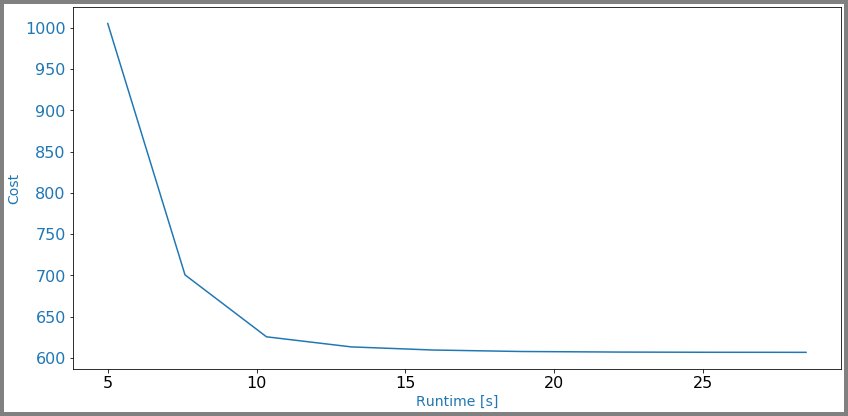

In [41]:
# step size new method
print("runtime = ", runtimeA)
print("cost = ", costA)
plotFunc.plot_conv_runtime(runtimeA, costA, path, filename_ = str('p1_e0_uInf_HighLow_convergence_time_' + alg))

In [ ]:
if not plot_only:
    plotFunc.plot_convergence(costA, path, filename_ = str('p1_e0_uInf_HighLow_cost_' + alg), ratio_ = 0.25)

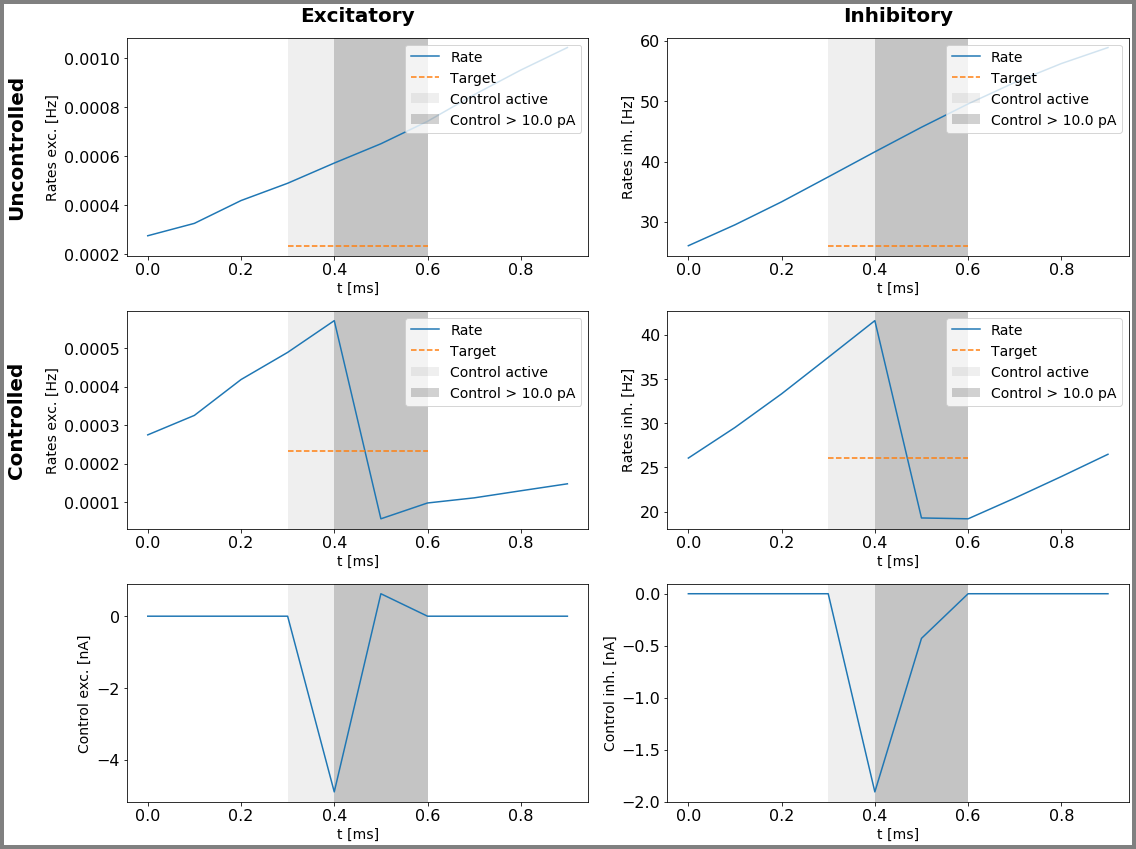

In [146]:
if not plot_only:
    plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e0_uInf_HighLow_' + alg) )

In [10]:
# B: precision only, max 1nA control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

set cost params


In [11]:
if not plot_only:
    if alg == "A1":
        bestControlB, bestStateB, costB, runtimeB, grad = aln.A1(init_1nA_hl, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlB, bestStateB, costB, runtimeB = aln.A2(control0, target_hl, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultB = {"Opt_control": bestControlB,
              "Opt_state": bestStateB,
              "costArray": costB,
              "runtimeArray": runtimeB,    
    }

    dump_dicts = [opt_params, aln.params, resultB]
    filename = str("B_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [12]:
if not plot_only:
    plotFunc.plot_convergence(costB, path, str("p1_e0_u1nA_HighLow_cost_" + alg))

In [13]:
if not plot_only:
    plotFunc.plot_control(aln, bestControlB, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e0_u1nA_HighLow_' + alg) )

In [14]:
# C: precision & energy equally penalize, free choice of control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

set cost params


In [15]:
if not plot_only:
    if alg == "A1":
        bestControlC, bestStateC, costC, runtimeC, grad = aln.A1(init_inf_hl, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlC, bestStateC, costC, runtimeC = aln.A2(control0, target_hl, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultC = {"Opt_control": bestControlC,
              "Opt_state": bestStateC,
              "costArray": costC,
              "runtimeArray": runtimeC,    
    }

    dump_dicts = [opt_params, aln.params, resultC]
    filename = str("C_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [16]:
if not plot_only:
    plotFunc.plot_convergence(costC, path, str("p1_e1_uInf_HighLow_cost_" + alg) )

In [17]:
if not plot_only:
    plotFunc.plot_control(aln, bestControlC, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e1_uInf_HighLow_' + alg) )

In [18]:
# D: precision & energy equally penalize, max 1nA control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = high_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = high_state_vars[sv]

set cost params


In [19]:
if not plot_only:
    if alg == "A1":
        bestControlD, bestStateD, costD, runtimeD, grad = aln.A1(init_1nA_hl, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlD, bestStateD, costD, runtimeD = aln.A2(control0, target_hl, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultD = {"Opt_control": bestControlD,
              "Opt_state": bestStateD,
              "costArray": costD,
              "runtimeArray": runtimeD,    
    }

    dump_dicts = [opt_params, aln.params, resultD]
    filename = str("D_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [20]:
if not plot_only:
    plotFunc.plot_convergence(costD, path, str("p1_e1_u1nA_HighLow_cost_" + alg) )

In [21]:
if not plot_only:
    plotFunc.plot_control(aln, bestControlD, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e1_u1nA_HighLow_' + alg))

### State switching low to high

In [71]:
# set high state rates as target
aln.params.duration = dur
max_it = 1000
plot_only = False
alg = "A1"

target_lh = aln.getZeroTarget()
target_lh[:,0,:] = steady_rates[1,0]
target_lh[:,1,:] = steady_rates[1,1]        

In [59]:
# E: precision only, free choice of control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv] 

set cost params


In [60]:
if not plot_only:
    if alg == "A1":
        bestControlE, bestStateE, costE, runtimeE = aln.A1(init_inf_lh, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlE, bestStateE, costE, runtimeE = aln.A2(control0, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultE = {"Opt_control": bestControlE,
              "Opt_state": bestStateE,
              "costArray": costE,
              "runtimeArray": runtimeE,    
    }      

    dump_dicts = [opt_params, aln.params, resultE]
    filename = str("E_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

RUN  0 , total integrated cost =  45740.55028557172
RUN  1 , total integrated cost =  11938.657330841877
RUN  2 , total integrated cost =  10355.72484738286
RUN  3 , total integrated cost =  8430.208601715556
RUN  4 , total integrated cost =  7301.143241601098
RUN  5 , total integrated cost =  6945.643274986676
RUN  6 , total integrated cost =  6659.075050071097
RUN  7 , total integrated cost =  6434.676287548722
RUN  8 , total integrated cost =  6239.598140336642
RUN  9 , total integrated cost =  6084.827510820205
RUN  10 , total integrated cost =  5779.441740632919
RUN  11 , total integrated cost =  5569.27862337278
RUN  12 , total integrated cost =  5476.861995447573
RUN  13 , total integrated cost =  5399.43086016896
RUN  14 , total integrated cost =  5315.393983652065
RUN  15 , total integrated cost =  5250.88161766683
RUN  16 , total integrated cost =  5176.949508874164
RUN  17 , total integrated cost =  5113.375149721115
RUN  18 , total integrated cost =  5047.943229203564
RUN  

RUN  153 , total integrated cost =  1828.8534774404136
RUN  154 , total integrated cost =  1803.8519846597724
RUN  155 , total integrated cost =  1751.0481925197817
RUN  156 , total integrated cost =  1721.475747784323
RUN  157 , total integrated cost =  1715.288551586602
RUN  158 , total integrated cost =  1712.083174060243
RUN  159 , total integrated cost =  1709.0961497845824
RUN  160 , total integrated cost =  1706.3043649584122
RUN  161 , total integrated cost =  1703.389371376162
RUN  162 , total integrated cost =  1700.6547366272735
RUN  163 , total integrated cost =  1697.4185584050692
RUN  164 , total integrated cost =  1694.0895027041
RUN  165 , total integrated cost =  1689.9570150812388
RUN  166 , total integrated cost =  1686.3055135341594
RUN  167 , total integrated cost =  1682.3043716658508
RUN  168 , total integrated cost =  1678.4553481270993
RUN  169 , total integrated cost =  1675.0844117933532
RUN  170 , total integrated cost =  1671.9713945779488
RUN  171 , total 

RUN  303 , total integrated cost =  1314.924752035582
RUN  304 , total integrated cost =  1313.8202676203719
RUN  305 , total integrated cost =  1312.7665246460865
RUN  306 , total integrated cost =  1311.7731210219854
RUN  307 , total integrated cost =  1310.6432500202582
RUN  308 , total integrated cost =  1309.5884003738092
RUN  309 , total integrated cost =  1308.484148442739
RUN  310 , total integrated cost =  1307.434879658028
RUN  311 , total integrated cost =  1306.3697298729548
RUN  312 , total integrated cost =  1305.3877769242529
RUN  313 , total integrated cost =  1304.292138518268
RUN  314 , total integrated cost =  1303.2975356013649
RUN  315 , total integrated cost =  1302.2680968692036
RUN  316 , total integrated cost =  1301.33979532019
RUN  317 , total integrated cost =  1300.2707168674985
RUN  318 , total integrated cost =  1299.1705295543654
RUN  319 , total integrated cost =  1297.5784729169395
RUN  320 , total integrated cost =  1296.2053414159363
RUN  321 , total

RUN  453 , total integrated cost =  1128.5151368719976
RUN  454 , total integrated cost =  1128.0675739569517
RUN  455 , total integrated cost =  1127.5747296495745
RUN  456 , total integrated cost =  1127.1013254835793
RUN  457 , total integrated cost =  1126.3436487312447
RUN  458 , total integrated cost =  1125.561921094975
RUN  459 , total integrated cost =  1123.2242204456675
RUN  460 , total integrated cost =  1121.0658819559071
RUN  461 , total integrated cost =  1119.113206496724
RUN  462 , total integrated cost =  1117.4272998715921
RUN  463 , total integrated cost =  1115.9168503186384
RUN  464 , total integrated cost =  1114.5274776805857
RUN  465 , total integrated cost =  1113.9344342518195
RUN  466 , total integrated cost =  1113.4868291822822
RUN  467 , total integrated cost =  1113.0055079949148
RUN  468 , total integrated cost =  1112.5337100115783
RUN  469 , total integrated cost =  1111.84591606144
RUN  470 , total integrated cost =  1111.1777687798326
RUN  471 , tot

RUN  603 , total integrated cost =  1041.569919236992
RUN  604 , total integrated cost =  1041.2847209015242
RUN  605 , total integrated cost =  1040.979234806679
RUN  606 , total integrated cost =  1040.7005386836363
RUN  607 , total integrated cost =  1040.4320640188141
RUN  608 , total integrated cost =  1040.1699566925865
RUN  609 , total integrated cost =  1039.902141876507
RUN  610 , total integrated cost =  1039.6471089037393
RUN  611 , total integrated cost =  1039.4197488333637
RUN  612 , total integrated cost =  1039.197966926611
RUN  613 , total integrated cost =  1038.981508037488
RUN  614 , total integrated cost =  1038.7672104366009
RUN  615 , total integrated cost =  1038.5486892699591
RUN  616 , total integrated cost =  1038.3311665452518
RUN  617 , total integrated cost =  1038.1215070670253
RUN  618 , total integrated cost =  1037.911451736732
RUN  619 , total integrated cost =  1037.7001630620985
RUN  620 , total integrated cost =  1037.4908647941563
RUN  621 , total

RUN  753 , total integrated cost =  1008.4902400484709
RUN  754 , total integrated cost =  1008.3004284646581
RUN  755 , total integrated cost =  1008.0971462251788
RUN  756 , total integrated cost =  1007.8910757679105
RUN  757 , total integrated cost =  1007.7063869246163
RUN  758 , total integrated cost =  1007.5222519112618
RUN  759 , total integrated cost =  1007.3205213569023
RUN  760 , total integrated cost =  1007.1218537124023
RUN  761 , total integrated cost =  1006.9398830051182
RUN  762 , total integrated cost =  1006.7497569494412
RUN  763 , total integrated cost =  1006.5638497579678
RUN  764 , total integrated cost =  1006.3814182434406
RUN  765 , total integrated cost =  1006.1913483156945
RUN  766 , total integrated cost =  1005.9938753683742
RUN  767 , total integrated cost =  1005.815650709472
RUN  768 , total integrated cost =  1005.6283872332297
RUN  769 , total integrated cost =  1005.4475563662089
RUN  770 , total integrated cost =  1005.2651396398878
RUN  771 , 

RUN  905 , total integrated cost =  982.9113988565329
RUN  906 , total integrated cost =  982.7484944199374
RUN  907 , total integrated cost =  982.5924339190046
RUN  908 , total integrated cost =  982.4332278849923
RUN  909 , total integrated cost =  982.2606214190657
RUN  910 , total integrated cost =  982.0828584155632
RUN  911 , total integrated cost =  981.9227740887587
RUN  912 , total integrated cost =  981.7535948795335
RUN  913 , total integrated cost =  981.5896406683504
RUN  914 , total integrated cost =  981.4282147662657
RUN  915 , total integrated cost =  981.2603760277002
RUN  916 , total integrated cost =  981.0861374583087
RUN  917 , total integrated cost =  980.9326011343533
RUN  918 , total integrated cost =  980.7776897947905
RUN  919 , total integrated cost =  980.6097390044847
RUN  920 , total integrated cost =  980.4430360102277
RUN  921 , total integrated cost =  980.2910466301264
RUN  922 , total integrated cost =  980.1321426519071
RUN  923 , total integrated 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  968.5989809630936
Improved over  1000  iterations by  97.88240636608907  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([8], dtype=int64)) 20.99462924086378
min value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([1], dtype=int64)) -11.307183400306545


runtime =  1055.8049730999992


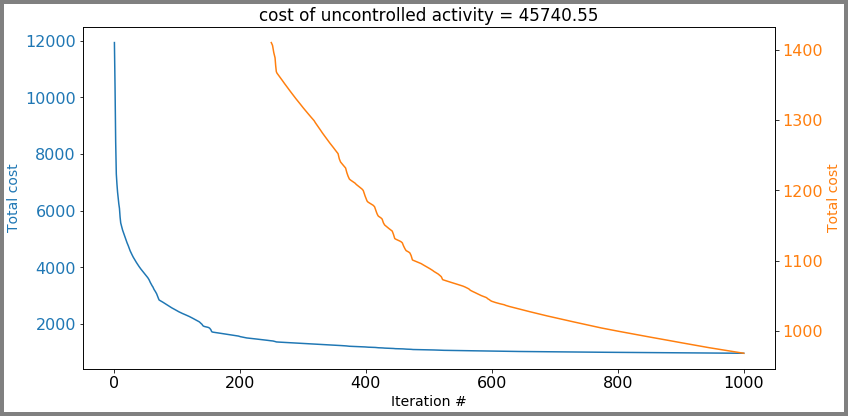

In [61]:
print("runtime = ", runtimeE[-1])

plotFunc.plot_convergence(costE, path, str("p1_e0_uInf_LowHigh_cost_" + alg))

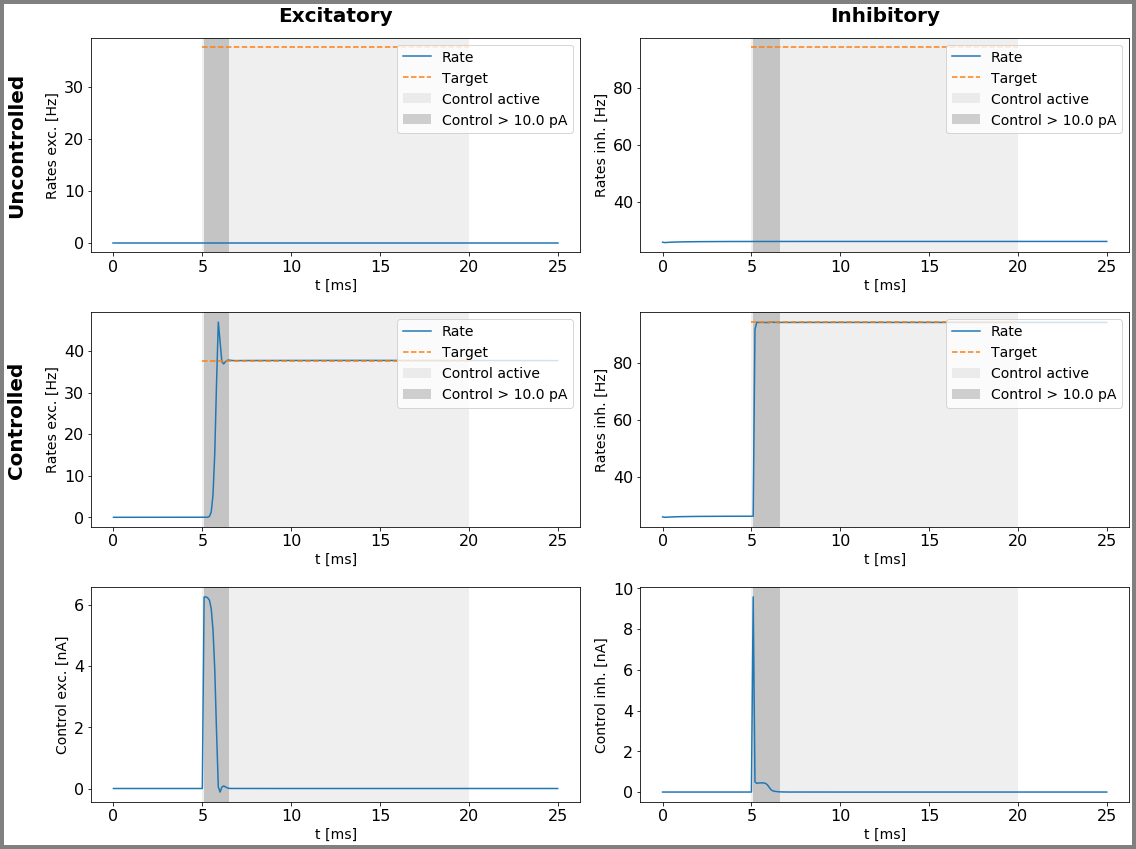

In [62]:
plotFunc.plot_control(aln, bestControlE, dur, dur_pre, dur_post, low_state_vars, target_lh, 
             path, filename_ = str('p1_e0_uInf_LowHigh_' + alg))

In [72]:
# F: precision only, max control
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]

set cost params


In [73]:
if not plot_only:
    if alg == "A1":
        bestControlF, bestStateF, costF, runtimeF = aln.A1(init_1nA_lh, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlF, bestStateF, costF, runtimeF = aln.A2(control0, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultF = {"Opt_control": bestControlF,
              "Opt_state": bestStateF,
              "costArray": costF,
              "runtimeArray": runtimeF,    
    }      

    dump_dicts = [opt_params, aln.params, resultF]
    filename = str("F_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

RUN  0 , total integrated cost =  45740.55028557172
choose exc, inh combination
RUN  1 , total integrated cost =  12067.08100219518
compute again =  12067.08100219518
choose exc, inh combination
RUN  2 , total integrated cost =  9242.198388055984
compute again =  9242.198388055984
choose exc, inh combination
RUN  3 , total integrated cost =  7460.648895719956
compute again =  7460.648895719956
choose inh only
RUN  4 , total integrated cost =  7002.969268726491
compute again =  6998.64772397251
choose joint computation
RUN  5 , total integrated cost =  6837.701261661576
compute again =  6837.701261661576
choose exc, inh combination
RUN  6 , total integrated cost =  6667.413930319816
compute again =  6667.413930319816
choose exc only
RUN  7 , total integrated cost =  6504.714084268406
compute again =  6504.714084268406
choose exc, inh combination
RUN  8 , total integrated cost =  6348.189146802598
compute again =  6348.189146802598
choose exc only
RUN  9 , total integrated cost =  6189.8

choose exc only
RUN  74 , total integrated cost =  3468.5623915764186
compute again =  3468.5623915764186
choose exc, inh combination
RUN  75 , total integrated cost =  3468.3297891473685
compute again =  3468.3297891473685
choose exc only
RUN  76 , total integrated cost =  3468.179280771705
compute again =  3468.179280771705
choose exc, inh combination
RUN  77 , total integrated cost =  3468.0346432956176
compute again =  3468.0346432956176
choose exc only
RUN  78 , total integrated cost =  3467.89848843724
compute again =  3467.89848843724
choose joint computation
RUN  79 , total integrated cost =  3467.7666338944964
compute again =  3467.7666338944964
choose exc only
RUN  80 , total integrated cost =  3467.639138849309
compute again =  3467.639138849309
choose exc, inh combination
RUN  81 , total integrated cost =  3467.517107360518
compute again =  3467.517107360518
choose exc only
RUN  82 , total integrated cost =  3467.398315086877
compute again =  3467.398315086877
choose exc, i

choose exc only
RUN  149 , total integrated cost =  3464.4223980736083
compute again =  3464.4223980736083
choose joint computation
RUN  150 , total integrated cost =  3464.413285098559
compute again =  3464.413285098559
choose exc only
RUN  151 , total integrated cost =  3464.404232127087
compute again =  3464.404232127087
choose exc, inh combination
RUN  152 , total integrated cost =  3464.3952426520464
compute again =  3464.3952426520464
choose exc only
RUN  153 , total integrated cost =  3464.3863669529974
compute again =  3464.3863669529974
choose exc, inh combination
RUN  154 , total integrated cost =  3464.377548406622
compute again =  3464.377548406622
choose exc only
RUN  155 , total integrated cost =  3464.368861528852
compute again =  3464.368861528852
choose joint computation
RUN  156 , total integrated cost =  3464.360308678153
compute again =  3464.360308678153
choose exc only
RUN  157 , total integrated cost =  3464.3518810324767
compute again =  3464.3518810324767
choos

choose exc only
RUN  224 , total integrated cost =  3463.9262540008044
compute again =  3463.9262540008044
choose exc only
RUN  225 , total integrated cost =  3463.92146610692
compute again =  3463.92146610692
choose exc only
RUN  226 , total integrated cost =  3463.916465202727
compute again =  3463.916465202727
choose exc, inh combination
RUN  227 , total integrated cost =  3463.9119739407415
compute again =  3463.9119739407415
choose exc only
RUN  228 , total integrated cost =  3463.9074101190236
compute again =  3463.9074101190236
choose exc, inh combination
RUN  229 , total integrated cost =  3463.9026123877943
compute again =  3463.9026123877943
choose exc only
RUN  230 , total integrated cost =  3463.8980296094846
compute again =  3463.8980296094846
choose exc only
RUN  231 , total integrated cost =  3463.8934660573113
compute again =  3463.8934660573113
choose exc only
RUN  232 , total integrated cost =  3463.888735862609
compute again =  3463.888735862609
choose exc, inh combi

choose exc, inh combination
RUN  299 , total integrated cost =  3463.6593275492723
compute again =  3463.6593275492723
choose exc only
RUN  300 , total integrated cost =  3463.6565984114095
compute again =  3463.6565984114095
choose exc only
RUN  301 , total integrated cost =  3463.6539123406096
compute again =  3463.6539123406096
choose exc only
RUN  302 , total integrated cost =  3463.6511019542377
compute again =  3463.6511019542377
choose exc, inh combination
RUN  303 , total integrated cost =  3463.6485948575773
compute again =  3463.6485948575773
choose exc only
RUN  304 , total integrated cost =  3463.646025107499
compute again =  3463.646025107499
choose exc, inh combination
RUN  305 , total integrated cost =  3463.6433361041254
compute again =  3463.6433361041254
choose exc only
RUN  306 , total integrated cost =  3463.6407479000077
compute again =  3463.6407479000077
choose exc only
RUN  307 , total integrated cost =  3463.6382135983786
compute again =  3463.6382135983786
cho

...

choose exc only
RUN  830 , total integrated cost =  3463.61989173134
compute again =  3463.61989173134
choose exc only
RUN  831 , total integrated cost =  3463.619890396009
compute again =  3463.619890396009
choose exc only
RUN  832 , total integrated cost =  3463.6198891068543
compute again =  3463.6198891068543
choose exc only
RUN  833 , total integrated cost =  3463.6198878433406
compute again =  3463.6198878433406
choose exc only
RUN  834 , total integrated cost =  3463.61988651137
compute again =  3463.61988651137
choose exc, inh combination
RUN  835 , total integrated cost =  3463.6198853044443
compute again =  3463.6198853044443
choose exc only
RUN  836 , total integrated cost =  3463.6198840916004
compute again =  3463.6198840916004
choose exc, inh combination
RUN  837 , total integrated cost =  3463.619882785591
compute again =  3463.619882785591
choose exc only
RUN  838 , total integrated cost =  3463.6198814482486
compute again =  3463.6198814482486
choose joint computation


choose exc only
RUN  906 , total integrated cost =  3463.6198130588255
compute again =  3463.6198130588255
choose exc only
RUN  907 , total integrated cost =  3463.61981224087
compute again =  3463.61981224087
choose exc only
RUN  908 , total integrated cost =  3463.6198114231647
compute again =  3463.6198114231647
choose exc only
RUN  909 , total integrated cost =  3463.6198106086968
compute again =  3463.6198106086968
choose exc only
RUN  910 , total integrated cost =  3463.6198098026034
compute again =  3463.6198098026034
choose exc only
RUN  911 , total integrated cost =  3463.619808991385
compute again =  3463.619808991385
choose exc only
RUN  912 , total integrated cost =  3463.6198081936477
compute again =  3463.6198081936477
choose exc only
RUN  913 , total integrated cost =  3463.6198074000126
compute again =  3463.6198074000126
choose exc only
RUN  914 , total integrated cost =  3463.6198066105
compute again =  3463.6198066105
choose exc only
RUN  915 , total integrated cost 

choose exc only
RUN  983 , total integrated cost =  3463.619758281344
compute again =  3463.619758281344
choose exc only
RUN  984 , total integrated cost =  3463.619757672692
compute again =  3463.619757672692
choose exc only
RUN  985 , total integrated cost =  3463.6197570835075
compute again =  3463.6197570835075
choose exc only
RUN  986 , total integrated cost =  3463.6197564929753
compute again =  3463.6197564929753
choose exc only
RUN  987 , total integrated cost =  3463.6197558972744
compute again =  3463.6197558972744
choose exc only
RUN  988 , total integrated cost =  3463.619755298863
compute again =  3463.619755298863
choose exc only
RUN  989 , total integrated cost =  3463.619754720347
compute again =  3463.619754720347
choose exc only
RUN  990 , total integrated cost =  3463.6197541397773
compute again =  3463.6197541397773
choose exc only
RUN  991 , total integrated cost =  3463.6197535549945
compute again =  3463.6197535549945
choose exc only
RUN  992 , total integrated c

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


choose exc only
RUN  1000 , total integrated cost =  3463.619748423938
compute again =  3463.619748423938
Improved over  1000  iterations by  92.4276823807332  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([43], dtype=int64)) 0.05841432697844956
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -361.4099452244545


runtime =  1041.943118700001


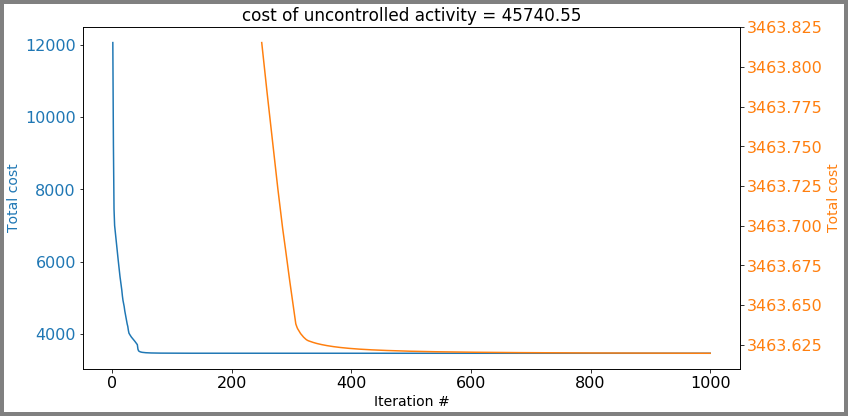

In [74]:
print("runtime = ", runtimeF[-1])

plotFunc.plot_convergence(costF, path, str("p1_e0_u1nA_LowHigh_cost_" + alg))

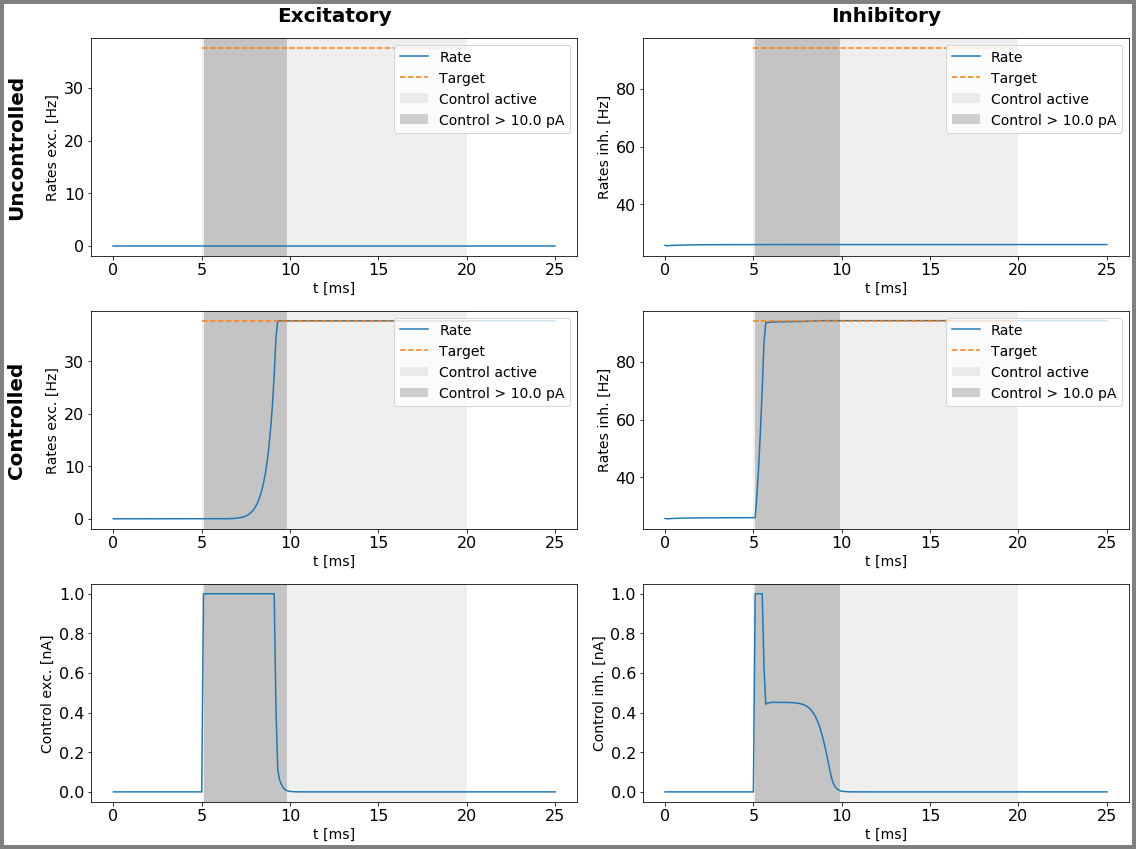

In [75]:
plotFunc.plot_control(aln, bestControlF, dur, dur_pre, dur_post, low_state_vars, target_lh,
             path, filename_ = str('p1_e0_u1nA_LowHigh_' + alg))

In [63]:
# G: precision and energy equally, free choice of control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1000. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]

set cost params


In [64]:
if not plot_only:
    if alg == "A1":
        bestControlG, bestStateG, costG, runtimeG = aln.A1(init_inf_lh, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlG, bestStateG, costG, runtimeG = aln.A2(control0, target_lh, max_iteration_ = max_it,
                    tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultG = {"Opt_control": bestControlG,
              "Opt_state": bestStateG,
              "costArray": costG,
              "runtimeArray": runtimeG,    
    }      

    dump_dicts = [opt_params, aln.params, resultG]
    filename = str("G_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

RUN  0 , total integrated cost =  45740.55028557172
RUN  1 , total integrated cost =  11994.625581225437
RUN  2 , total integrated cost =  10414.305180862906
RUN  3 , total integrated cost =  8507.302778824871
RUN  4 , total integrated cost =  7361.3125362614555
RUN  5 , total integrated cost =  7002.290587805653
RUN  6 , total integrated cost =  6719.790813628415
RUN  7 , total integrated cost =  6496.3796384672605
RUN  8 , total integrated cost =  6161.119882285908
RUN  9 , total integrated cost =  5931.275936646021
RUN  10 , total integrated cost =  5808.025918144815
RUN  11 , total integrated cost =  5694.612822623283
RUN  12 , total integrated cost =  5578.162927936924
RUN  13 , total integrated cost =  5481.805940600088
RUN  14 , total integrated cost =  5350.803154054375
RUN  15 , total integrated cost =  5247.46792802644
RUN  16 , total integrated cost =  5123.8174698725925
RUN  17 , total integrated cost =  5024.879096002054
RUN  18 , total integrated cost =  4936.554727764253

RUN  153 , total integrated cost =  2103.14175572449
RUN  154 , total integrated cost =  2097.722087238425
RUN  155 , total integrated cost =  2092.3562528547486
RUN  156 , total integrated cost =  2086.5858851437447
RUN  157 , total integrated cost =  2080.8421797343567
RUN  158 , total integrated cost =  2073.941082274659
RUN  159 , total integrated cost =  2067.0117639622804
RUN  160 , total integrated cost =  2060.9320757834457
RUN  161 , total integrated cost =  2055.520004792658
RUN  162 , total integrated cost =  2049.743835287314
RUN  163 , total integrated cost =  2043.6612174642537
RUN  164 , total integrated cost =  2037.1688784384655
RUN  165 , total integrated cost =  2030.887031730529
RUN  166 , total integrated cost =  2025.3087207925487
RUN  167 , total integrated cost =  2020.0590353189914
RUN  168 , total integrated cost =  2013.864965468685
RUN  169 , total integrated cost =  2007.900793633525
RUN  170 , total integrated cost =  2001.6920294501297
RUN  171 , total in

RUN  303 , total integrated cost =  1667.2386089946917
RUN  304 , total integrated cost =  1665.90134956882
RUN  305 , total integrated cost =  1664.5458421586918
RUN  306 , total integrated cost =  1663.2959052621086
RUN  307 , total integrated cost =  1662.0845754423797
RUN  308 , total integrated cost =  1660.913101876397
RUN  309 , total integrated cost =  1659.7666120445056
RUN  310 , total integrated cost =  1658.6108448512512
RUN  311 , total integrated cost =  1657.4361889688855
RUN  312 , total integrated cost =  1656.1210939570822
RUN  313 , total integrated cost =  1654.8943743304583
RUN  314 , total integrated cost =  1653.764330397933
RUN  315 , total integrated cost =  1652.6211225760824
RUN  316 , total integrated cost =  1651.337779916033
RUN  317 , total integrated cost =  1650.1219188067823
RUN  318 , total integrated cost =  1648.9460325134921
RUN  319 , total integrated cost =  1647.781445836764
RUN  320 , total integrated cost =  1646.6427033292498
RUN  321 , total

RUN  453 , total integrated cost =  1537.975549719784
RUN  454 , total integrated cost =  1537.39147048075
RUN  455 , total integrated cost =  1536.8118407937577
RUN  456 , total integrated cost =  1536.221028285755
RUN  457 , total integrated cost =  1535.653821823054
RUN  458 , total integrated cost =  1535.0718656754168
RUN  459 , total integrated cost =  1534.4880768641726
RUN  460 , total integrated cost =  1533.887569541251
RUN  461 , total integrated cost =  1533.3137798308803
RUN  462 , total integrated cost =  1532.7394400256335
RUN  463 , total integrated cost =  1532.167420976807
RUN  464 , total integrated cost =  1531.581732705653
RUN  465 , total integrated cost =  1531.0178227440572
RUN  466 , total integrated cost =  1530.4387510789727
RUN  467 , total integrated cost =  1529.8515967322749
RUN  468 , total integrated cost =  1529.2629985050828
RUN  469 , total integrated cost =  1528.7008293283332
RUN  470 , total integrated cost =  1528.1358786759915
RUN  471 , total i

RUN  603 , total integrated cost =  1465.2714879363923
RUN  604 , total integrated cost =  1464.8663210283248
RUN  605 , total integrated cost =  1464.5049653241654
RUN  606 , total integrated cost =  1464.12590762737
RUN  607 , total integrated cost =  1463.7545428184799
RUN  608 , total integrated cost =  1463.3886048602253
RUN  609 , total integrated cost =  1462.9908133803651
RUN  610 , total integrated cost =  1462.6030930574839
RUN  611 , total integrated cost =  1462.241812924886
RUN  612 , total integrated cost =  1461.8768096971755
RUN  613 , total integrated cost =  1461.5023534545364
RUN  614 , total integrated cost =  1461.1101265635302
RUN  615 , total integrated cost =  1460.763896328435
RUN  616 , total integrated cost =  1460.3946795967986
RUN  617 , total integrated cost =  1460.0374474060206
RUN  618 , total integrated cost =  1459.6886894052054
RUN  619 , total integrated cost =  1459.3161175381113
RUN  620 , total integrated cost =  1458.943479801747
RUN  621 , tota

RUN  753 , total integrated cost =  1420.290444085708
RUN  754 , total integrated cost =  1420.0555226250929
RUN  755 , total integrated cost =  1419.8203802591324
RUN  756 , total integrated cost =  1419.581064980731
RUN  757 , total integrated cost =  1419.3550740403057
RUN  758 , total integrated cost =  1419.130106182412
RUN  759 , total integrated cost =  1418.8962313163793
RUN  760 , total integrated cost =  1418.6560341905283
RUN  761 , total integrated cost =  1418.4417065443909
RUN  762 , total integrated cost =  1418.2159305550554
RUN  763 , total integrated cost =  1417.9941354762302
RUN  764 , total integrated cost =  1417.780257864848
RUN  765 , total integrated cost =  1417.5495622769818
RUN  766 , total integrated cost =  1417.3217128175284
RUN  767 , total integrated cost =  1417.1093752364018
RUN  768 , total integrated cost =  1416.8938160756006
RUN  769 , total integrated cost =  1416.6732666131575
RUN  770 , total integrated cost =  1416.4431606453923
RUN  771 , tot

RUN  903 , total integrated cost =  1391.6059542843807
RUN  904 , total integrated cost =  1391.4479848385872
RUN  905 , total integrated cost =  1391.2909500769256
RUN  906 , total integrated cost =  1391.1412504473963
RUN  907 , total integrated cost =  1390.9776616632607
RUN  908 , total integrated cost =  1390.81751600613
RUN  909 , total integrated cost =  1390.66716515617
RUN  910 , total integrated cost =  1390.5153785629852
RUN  911 , total integrated cost =  1390.3595974770806
RUN  912 , total integrated cost =  1390.1967100985446
RUN  913 , total integrated cost =  1390.053483199656
RUN  914 , total integrated cost =  1389.9000003259616
RUN  915 , total integrated cost =  1389.751869057772
RUN  916 , total integrated cost =  1389.6066558205828
RUN  917 , total integrated cost =  1389.4536976034467
RUN  918 , total integrated cost =  1389.2980464892244
RUN  919 , total integrated cost =  1389.1576103963635
RUN  920 , total integrated cost =  1389.0109757125238
RUN  921 , total

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  1378.227731812022
Improved over  1000  iterations by  96.98685799972378  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([10], dtype=int64)) 19.151865730718306
min value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([1], dtype=int64)) -7.2971878089416045


runtime =  1191.3293154999992


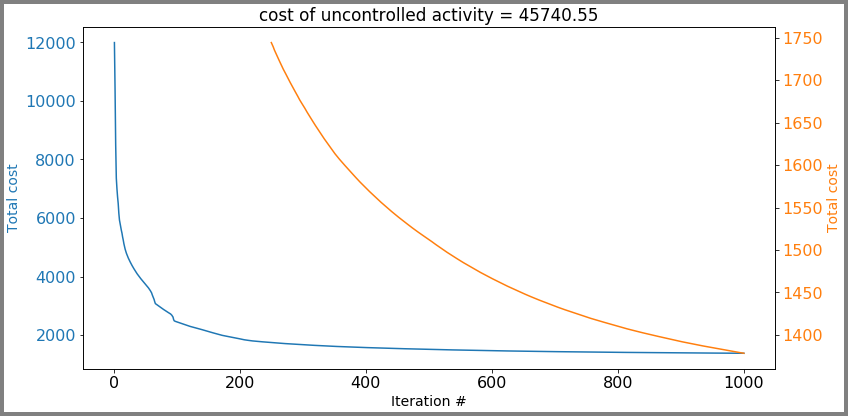

In [65]:
print("runtime = ", runtimeG[-1])

plotFunc.plot_convergence(costG, path, str("p1_e1_uInf_LowHigh_cost_" + alg))

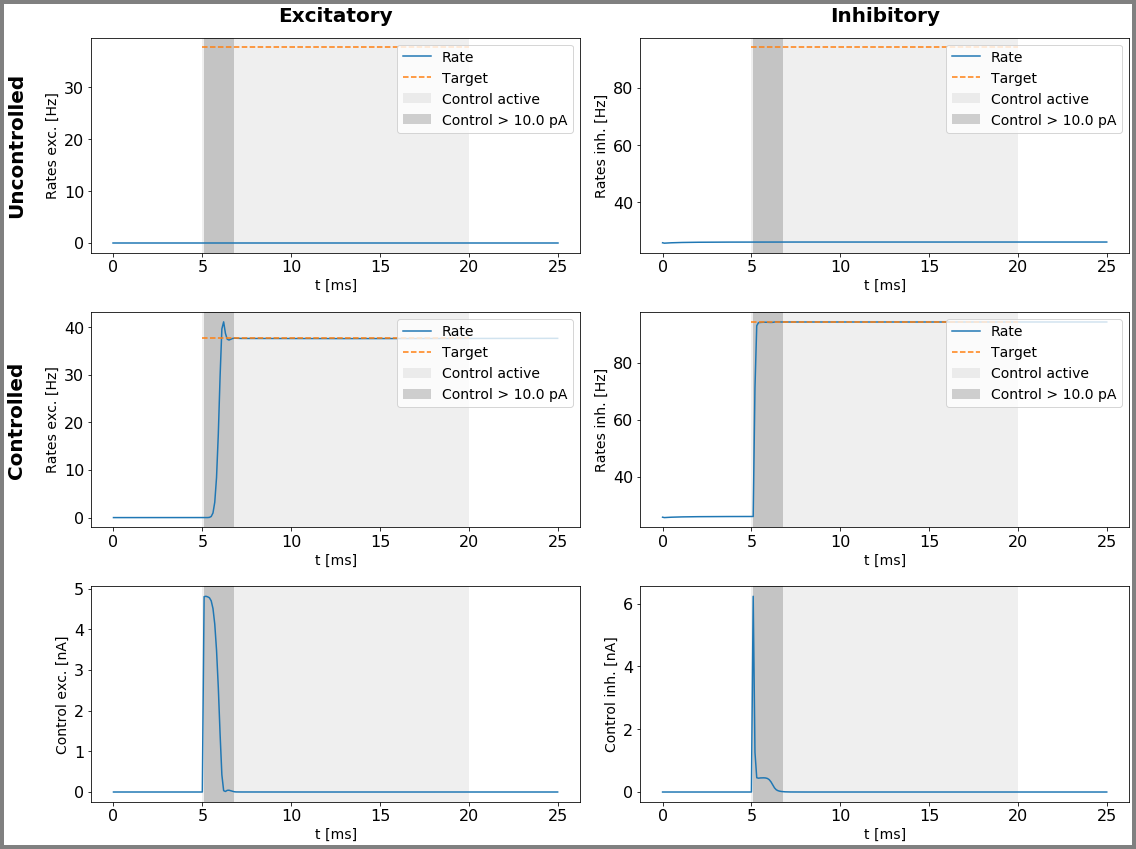

In [66]:
plotFunc.plot_control(aln, bestControlG, dur, dur_pre, dur_post, low_state_vars, target_lh, 
             path, filename_= str('p1_e1_uInf_LowHigh_' + alg))

In [ ]:
# F: precision and energy equally, max control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

for iv in range(len(init_vars)):
    for sv in range(len(state_vars)):
        if state_vars[sv] in init_vars[iv]:
            if aln.params[init_vars[iv]].ndim == 2:
                aln.params[init_vars[iv]][0,0] = low_state_vars[sv]
            else:
                aln.params[init_vars[iv]][0] = low_state_vars[sv]

In [ ]:
if not plot_only:
    if alg == "A1":
        bestControlH, bestStateH, costH, runtimeH = aln.A1(init_1nA_lh, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlH, bestStateH, costH, runtimeH = aln.A2(control0, target_lh, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultH = {"Opt_control": bestControlH,
              "Opt_state": bestStateH,
              "costArray": costH,
              "runtimeArray": runtimeH,    
    }      

    dump_dicts = [opt_params, aln.params, resultH]
    filename = str("H_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

In [ ]:
print("runtime = ", runtimeG)

plotFunc.plot_convergence(costH, path, str("p1_e1_u1nA_LowHigh_cost_" + alg))

In [ ]:
plotFunc.plot_control(aln, bestControlH, dur, dur_pre, dur_post, low_state_vars, target_lh, 
             path, filename_ = str('p1_e1_u1nA_LowHigh_' + alg))